In [1]:
import pickle
from pathlib import Path

import numpy as np
import tools_file
import tools_augment

# 批量处理 MOTN 文件
MOTN_DIR = Path("AR")
SAVE_PATH = Path("data/ar_motn.pkl")
TARGET_HZ = 200.0
GRIPPER_WIDTH = 0.0

# 数据增广设置：默认保存 原始 + XZ/YZ/XY 平面镜像，再对这 4 条各自倒放
AUGMENT_MIRROR_PLANES = ("xz", "yz", "xy")
AUGMENT_REVERSE = True
INCLUDE_ORIGINAL = True

motn_files = sorted(MOTN_DIR.rglob("*.motn"))

### 批量处理并保存

In [2]:
def matrix_to_rotvec(mat):
    mat = np.asarray(mat, dtype=float)
    cos_angle = (np.trace(mat) - 1.0) / 2.0
    cos_angle = np.clip(cos_angle, -1.0, 1.0)
    angle = np.arccos(cos_angle)

    if angle < 1e-8:
        return np.zeros(3)

    axis = np.array(
        [
            mat[2, 1] - mat[1, 2],
            mat[0, 2] - mat[2, 0],
            mat[1, 0] - mat[0, 1],
        ]
    ) / (2.0 * np.sin(angle))

    return axis * angle


def matrices_to_rotvec(mats):
    return np.asarray([matrix_to_rotvec(mat) for mat in mats], dtype=float)


def motn_to_traj(
    motn_path: Path,
    *,
    target_hz: float | None = TARGET_HZ,
    rot_resample_method: str = "squad",
):
    # .motn file to transform matrix sequence
    ee_tf = tools_file.motn_to_tf(path=motn_path)

    # resampling
    if target_hz is not None:
        ee_tf = tools_file.tfs_resample_tfs([ee_tf], target_fps=target_hz, padding=False)[0]

    # tf to position + axis-angle
    traj = {
        "t": ee_tf["t"].astype(float),
        "ee_tf": ee_tf["tf"],
        "ee_pos": ee_tf["tf"][:, :3, 3],
        "ee_axis_angle": matrices_to_rotvec(ee_tf["tf"][:, :3, :3]),
        "gripper_width": ee_tf["gripper_width"],
    }

    return traj


def motn_to_pkl(
    motn_dir: Path,
    save_path: Path,
    *,
    target_hz: float | None = TARGET_HZ,
    rot_resample_method: str = "squad",
    augment_mirror_planes = AUGMENT_MIRROR_PLANES,
    augment_reverse: bool = AUGMENT_REVERSE,
):
    motn_dir = Path(motn_dir)
    save_path = Path(save_path)

    motn_files = sorted(motn_dir.rglob("*.motn"))
    if len(motn_files) == 0:
        raise FileNotFoundError(f"No .motn files found under {motn_dir}")

    data = []
    print("motn files:", len(motn_files))
    print(
        "augmentation:",
        f"mirror_planes={augment_mirror_planes}",
        f"reverse={augment_reverse}",
    )

    for motn_path in motn_files:
        traj = motn_to_traj(
            motn_path,
            target_hz=target_hz,
            rot_resample_method=rot_resample_method,
        )
        variants = tools_augment.augment_traj(
            traj,
            mirror_planes=augment_mirror_planes,
            reverse=augment_reverse,
        )
        data.extend(variants)

        duration = traj["t"][-1]
        fps = round((len(traj["t"]) - 1) / duration, 3) if duration > 0 else 0
        print(
            motn_path.name,
            "frames =", len(traj["t"]),
            "duration =", round(float(duration), 3),
            "fps =", fps,
            "variants =", len(variants),
        )

    save_path.parent.mkdir(parents=True, exist_ok=True)
    with open(save_path, "wb") as f:
        pickle.dump(data, f)

    print("saved:", save_path)
    print("num source trajectories:", len(motn_files))
    print("num saved trajectories:", len(data))
    return data

In [3]:
trajectories = motn_to_pkl(
    MOTN_DIR,
    SAVE_PATH,
    target_hz=TARGET_HZ,
    augment_mirror_planes=AUGMENT_MIRROR_PLANES,
    augment_reverse=AUGMENT_REVERSE,
)

motn files: 94
augmentation: mirror_planes=('xz', 'yz', 'xy') reverse=True
2026_05_10_1657480430.motn frames = 887 duration = 4.433 fps = 199.85 variants = 16
2026_05_10_1658011620.motn frames = 1020 duration = 5.1 fps = 199.804 variants = 16
2026_05_10_1658389050.motn frames = 690 duration = 3.45 fps = 199.71 variants = 16
2026_05_10_1658459530.motn frames = 757 duration = 3.783 fps = 199.824 variants = 16
2026_05_10_1706048040.motn frames = 783 duration = 3.917 fps = 199.66 variants = 16
2026_05_10_1706176230.motn frames = 697 duration = 3.483 fps = 199.809 variants = 16
2026_05_12_1645225600.motn frames = 2200 duration = 11.0 fps = 199.909 variants = 16
2026_05_12_1645406310.motn frames = 2290 duration = 11.45 fps = 199.913 variants = 16
2026_05_12_1645590510.motn frames = 1847 duration = 9.233 fps = 199.928 variants = 16
2026_05_12_1646158880.motn frames = 2083 duration = 10.417 fps = 199.872 variants = 16
2026_05_12_1646311910.motn frames = 2210 duration = 11.05 fps = 199.91 varia

### Debug 绘图

In [4]:
import matplotlib.pyplot as plt

def PLOT_RAW(raw):
    pos_source   = raw["position_source"]
    euler_source = raw["euler_source"]

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.plot(pos_source[:, 0], label="X")
    plt.plot(pos_source[:, 1], label="Y")
    plt.plot(pos_source[:, 2], label="Z")
    plt.xlabel("Time")
    plt.ylabel("Position")
    plt.title("Position over Time")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(euler_source[:, 0], label="X")
    plt.plot(euler_source[:, 1], label="Y")
    plt.plot(euler_source[:, 2], label="Z")
    plt.xlabel("Time")
    plt.ylabel("Euler Angles")
    plt.title("Euler Angles over Time")
    plt.legend()

    plt.tight_layout()
    plt.show()

def PLOT_POS_RAW(raw, type="xy"):
    match type:
        case "xy":
            plt.plot(raw["position_source"][:, 0], raw["position_source"][:, 1])
            plt.xlabel("X Position")
            plt.ylabel("Y Position")
            plt.title("XY Position Plot")
        case "xz":
            plt.plot(raw["position_source"][:, 0], raw["position_source"][:, 2])
            plt.xlabel("X Position")
            plt.ylabel("Z Position")
            plt.title("XZ Position Plot")
        case "yz":
            plt.plot(raw["position_source"][:, 1], raw["position_source"][:, 2])
            plt.xlabel("Y Position")
            plt.ylabel("Z Position")
            plt.title("YZ Position Plot")
        case _:
            raise ValueError("type must be 'xy', 'xz', or 'yz'")
    plt.show()

def PLOT_3D(tf, 
            arrow_scale = 0.05, 
            interval: float = 0.1,
            view:str = "normal"):
    
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(tf[:, 0, 3], tf[:, 1, 3], tf[:, 2, 3])
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    # 绘制 orientation
    for i in range(0, len(tf), max(1, int(len(tf)*interval))):  # 每隔一定数量的帧绘制一个坐标轴
        T = tf[i]
        origin = T[:3, 3]
        x_axis = origin + T[:3, 0] * arrow_scale  # X轴，红色
        y_axis = origin + T[:3, 1] * arrow_scale  # Y轴，绿色
        z_axis = origin + T[:3, 2] * arrow_scale  # Z轴，蓝色
        ax.plot([origin[0], x_axis[0]], [origin[1], x_axis[1]], [origin[2], x_axis[2]], color='r')
        ax.plot([origin[0], y_axis[0]], [origin[1], y_axis[1]], [origin[2], y_axis[2]], color='g')
        ax.plot([origin[0], z_axis[0]], [origin[1], z_axis[1]], [origin[2], z_axis[2]], color='b')

    match view.lower():
        case "normal":
            pass  # 使用默认视角
        case "top":
            # ax.view_init(elev=90, azim=-90)
            ax.view_init(elev=90, azim=-180)
        case "side":
            ax.view_init(elev=0, azim=-90)
        case "front":
            ax.view_init(elev=0, azim=0)


    xyz = tf[:, :3, 3]
    mins = xyz.min(axis=0)
    maxs = xyz.max(axis=0)
    center = (mins + maxs) / 2
    radius = (maxs - mins).max() / 2

    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)
    ax.set_box_aspect((1, 1, 1))
    ax.set_proj_type("ortho")

    plt.show()

In [5]:
def axis_angle_to_matrix(axis_angle):
    axis_angle = np.asarray(axis_angle, dtype=float)
    angle = np.linalg.norm(axis_angle)
    if angle < 1e-8:
        return np.eye(3)

    axis = axis_angle / angle
    x, y, z = axis
    c = np.cos(angle)
    s = np.sin(angle)
    C = 1.0 - c

    return np.array(
        [
            [c + x * x * C, x * y * C - z * s, x * z * C + y * s],
            [y * x * C + z * s, c + y * y * C, y * z * C - x * s],
            [z * x * C - y * s, z * y * C + x * s, c + z * z * C],
        ],
        dtype=float,
    )


def load_pkl_trajectories(path=SAVE_PATH):
    with open(path, "rb") as f:
        return pickle.load(f)


def _set_equal_3d_axes(ax, xyz):
    mins = xyz.min(axis=0)
    maxs = xyz.max(axis=0)
    center = (mins + maxs) / 2
    radius = (maxs - mins).max() / 2
    if radius < 1e-8:
        radius = 1e-3

    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)
    ax.set_box_aspect((1, 1, 1))
    ax.set_proj_type("ortho")


def _apply_3d_view(ax, view):
    match view.lower():
        case "normal":
            pass
        case "top":
            ax.view_init(elev=90, azim=-180)
        case "side":
            ax.view_init(elev=0, azim=-90)
        case "front":
            ax.view_init(elev=0, azim=0)
        case _:
            raise ValueError("3D view must be 'normal', 'top', 'side', or 'front'")


def PLOT_PKL(
    index: int = 0,
    view: str = "xy",
    num: int = 4,
    *,
    data=None,
    pkl_path=SAVE_PATH,
    interval: float = 0.02,
    axis_len: float = 0.04,
    titles=None,
):
    if data is None:
        data = load_pkl_trajectories(pkl_path)

    if index < 0 or index >= len(data):
        raise IndexError(f"index must be in [0, {len(data) - 1}]")

    end = min(index + num, len(data))
    plot_indices = list(range(index, end))
    cols = min(4, len(plot_indices))
    rows = int(np.ceil(len(plot_indices) / cols))

    view = view.lower()
    projection_axes = {
        "xy": (0, 1, "X", "Y"),
        "xz": (0, 2, "X", "Z"),
        "yz": (1, 2, "Y", "Z"),
    }


    fig = plt.figure(figsize=(4.5 * cols, 4.5 * rows))

    for plot_id, data_idx in enumerate(plot_indices):
        traj = np.asarray(data[data_idx]["ee_pos"], dtype=float)
        axis_angle = np.asarray(data[data_idx]["ee_axis_angle"], dtype=float)
        step = max(1, int(len(traj) * interval))

        ax = fig.add_subplot(rows, cols, plot_id + 1, projection="3d")
        ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], linewidth=1.5)
        ax.scatter(traj[0, 0], traj[0, 1], traj[0, 2], c="g", marker="o", s=35)
        ax.scatter(traj[-1, 0], traj[-1, 1], traj[-1, 2], c="r", marker="x", s=35)

        # 绘制 orientation
        for i in range(0, len(traj), step):
            p = traj[i]
            rot = axis_angle_to_matrix(axis_angle[i])
            ax.quiver(p[0], p[1], p[2], rot[0, 0], rot[1, 0], rot[2, 0], length=axis_len, normalize=True, color="r")
            ax.quiver(p[0], p[1], p[2], rot[0, 1], rot[1, 1], rot[2, 1], length=axis_len, normalize=True, color="g")
            ax.quiver(p[0], p[1], p[2], rot[0, 2], rot[1, 2], rot[2, 2], length=axis_len, normalize=True, color="b")

        _set_equal_3d_axes(ax, traj)
        _apply_3d_view(ax, view)
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")


        if titles is not None and plot_id < len(titles):
            ax.set_title(titles[plot_id])
        else:
            ax.set_title(f"Trajectory index: {data_idx}")

    plt.tight_layout()
    plt.show()

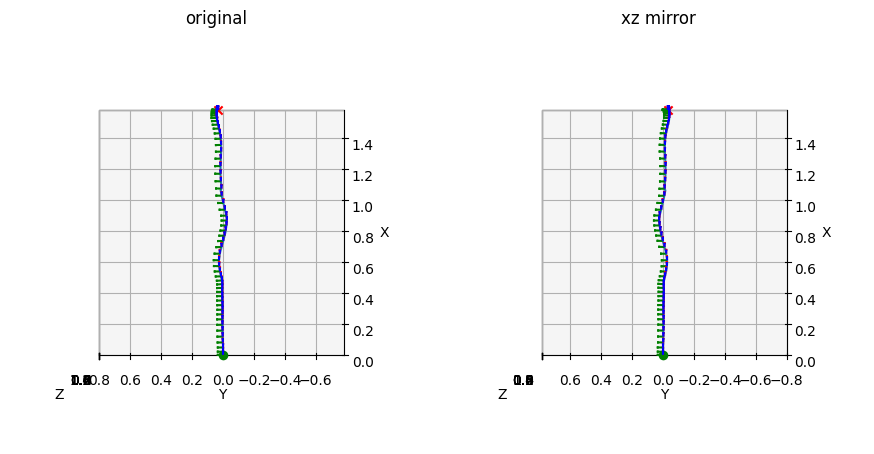

In [6]:
# 保存后的增广顺序是 original, xz mirror, yz mirror, xy mirror, reverse(...)
# 这里画前 2 条：原始轨迹 + XZ 平面镜像轨迹
PLOT_PKL(
    index=0,
    view="top",
    num=2,
    titles=["original", "xz mirror"],
)

### 单文件 Debug 处理流程

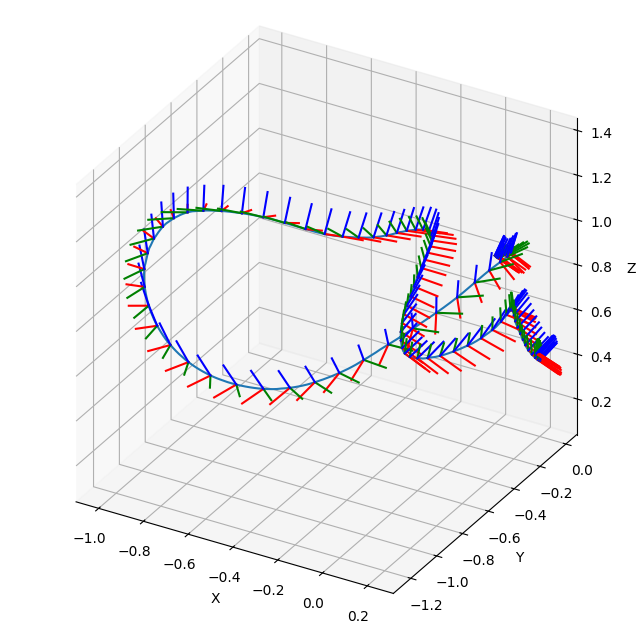

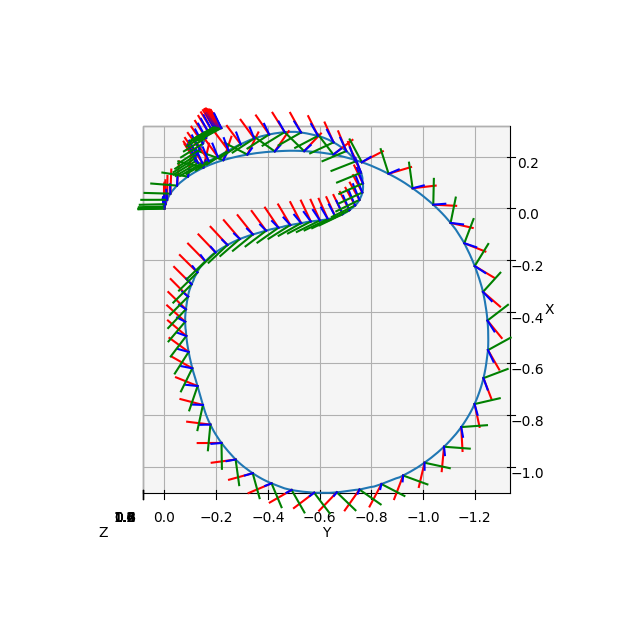

In [7]:
INPUT_PATH = Path("/home/ece-486/Documents/SP_PBL/umi-on-legs/AR/spin/2026_05_12_2021281130/2026_05_12_2021281130.motn")
INPUT_PATH = Path("/home/ece-486/Documents/SP_PBL/umi-on-legs/AR/reach_forward/2026_05_10_2137198790/2026_05_10_2137198790.motn")
INPUT_PATH = Path("/home/ece-486/Documents/SP_PBL/umi-on-legs/AR_test/2026_05_14_0052274540/2026_05_14_0052274540.motn")
INPUT_PATH = Path("/home/ece-486/Documents/SP_PBL/umi-on-legs/AR/rotate/2026_05_14_0107306890/2026_05_14_0107306890.motn")

single_data = tools_file.motn_to_tf(path=INPUT_PATH)

tf = single_data["tf"]

ARROW = 0.1
PLOT_3D(tf, arrow_scale=ARROW, interval=0.01, view="normal")
PLOT_3D(tf, arrow_scale=ARROW, interval=0.01, view="top")
# PLOT_3D(tf, arrow_scale=ARROW, interval=0.01, view="side")

### XZ 镜像 Debug 可视化

In [ ]:
# 使用当前 INPUT_PATH，不依赖已保存的 pkl。
# TOP 视角下可以直接检查 XZ 镜像是否让 y 方向对称翻转。
debug_original = motn_to_traj(
    INPUT_PATH,
    target_hz=TARGET_HZ,
)

debug_xz_mirror = tools_augment.mirror_xz_episode(debug_original)
debug_yz_mirror = tools_augment.mirror_yz_episode(debug_original)
debug_xz_yz_mirror = tools_augment.mirror_yz_episode(tools_augment.mirror_xz_episode(debug_original))
debug_backward = tools_augment.reverse_episode(debug_original)

PLOT_PKL(
    index=0,
    view="top",
    num=2,
    data=[debug_original, debug_xz_mirror,],
    titles=["original", "xz mirror"],
)

PLOT_PKL(
    index=0,
    view="top",
    num=2,
    data=[debug_yz_mirror, debug_xz_yz_mirror,],
    titles=["yz mirror", "xz-yz mirror"],
)

PLOT_PKL(
    index=0,
    view="top",
    num=2,
    data=[debug_backward,],
    titles=["reverse"],
)

TypeError: motn_to_traj() got an unexpected keyword argument 'gripper_width'